# **To check these notebooks, the first one is timeseries where i explored the maximum and i tried a lot of things and i put all my remarks and ideas and put hypothisis and try to answer them later the second one forecasting based on cnt is the one where i do the assignment without diving a lot.**

In [326]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

## **Exploring Data**

In [327]:
df = pd.read_csv('bike_sharing_per_day.csv')

In [328]:
df.shape

(731, 16)

In [329]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


- **instant**: Record index
- **dteday**: Date
- **season**: Season (1:springer, 2:summer, 3:fall, 4:winter)
- **yr**: Year (0: 2011, 1:2012)
- **mnth**: Month (1 to 12)
- **holiday**: weather day is holiday or not (extracted from Holiday Schedule)
- **weekday**: Day of the week
- **workingday**: If day is neither weekend nor holiday is 1, otherwise is 0.
- **weathersit**: (extracted from Freemeteo)

1: Clear, Few clouds, Partly cloudy, Partly cloudy

2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

- **temp**: Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- **atemp**: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- **hum**: Normalized humidity. The values are divided to 100 (max)
- **windspeed**: Normalized wind speed. The values are divided to 67 (max)
- **casual**: count of casual users
- **registered**: count of registered users
- **cnt**: count of total rental bikes including both casual and registered

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Trying to pick the best second feature to use : i will pick one and iterate to make it better 

First pick : registered

Second pick : casual

Third pick : temp


In [331]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [332]:
df_heatmap = df[['season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt']]


<Axes: >

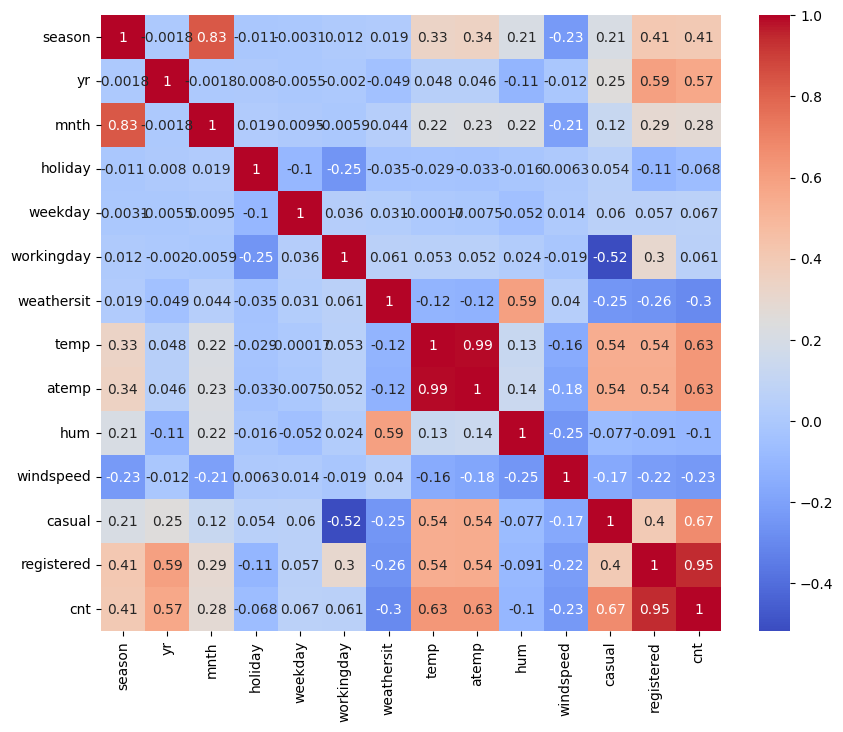

In [333]:
plt.figure(figsize=(10,8))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm')

Trying to pick the best second feature to use : i will pick one and iterate to make it better 

First pick : registered

Second pick : casual

Third pick : temp


In [334]:
df_to_use = df[['dteday', 'cnt', 'registered']]

In [335]:
df_to_use['dteday'] = pd.to_datetime(df_to_use['dteday'])

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_9368\2731951805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use['dteday'] = pd.to_datetime(df_to_use['dteday'])


In [336]:
df_to_use.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   cnt         731 non-null    int64         
 2   registered  731 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 17.3 KB


In [337]:
df_to_use.isnull().sum()

dteday        0
cnt           0
registered    0
dtype: int64

This dataset should be cleaned before using it because it will create problems later on.

In [338]:
df_to_use.dropna(inplace=True)

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_9368\1691188311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use.dropna(inplace=True)


In [339]:
df_to_use.shape

(731, 3)

In [340]:
df_to_use.duplicated().sum()

0

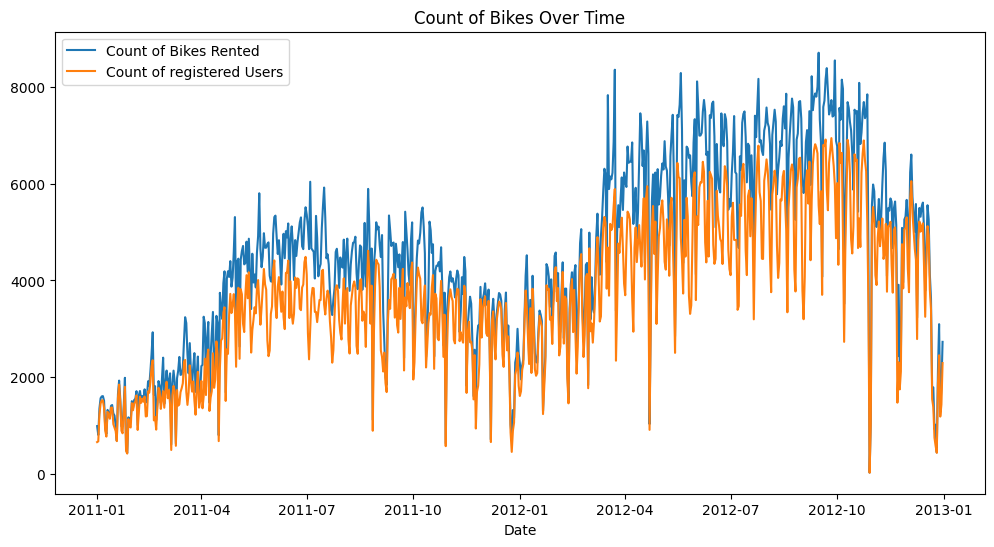

In [341]:
plt.figure(figsize=(12, 6))
plt.plot(df_to_use['dteday'], df_to_use['cnt'], label='Count of Bikes Rented')
plt.plot(df_to_use['dteday'], df_to_use['registered'], label='Count of registered Users')
plt.xlabel('Date')
plt.title('Count of Bikes Over Time')
plt.legend()
plt.show()

In [342]:
df_to_use.head()

,dteday,cnt,registered
0,2011-01-01,985,654
1,2011-01-02,801,670
2,2011-01-03,1349,1229
3,2011-01-04,1562,1454
4,2011-01-05,1600,1518


# CNN Time Series

## **Data Manipulation**

In [343]:
value_column = 'cnt'
second_column = 'registered'
scaler = MinMaxScaler()
df_to_use[[value_column]] = scaler.fit_transform(df_to_use[[value_column]])
df_to_use[[second_column]] = scaler.fit_transform(df_to_use[[second_column]])
df_to_use.head()

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_9368\1055931592.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use[[value_column]] = scaler.fit_transform(df_to_use[[value_column]])
C:\Users\Chourouk\AppData\Local\Temp\ipykernel_9368\1055931592.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use[[second_column]] = scaler.fit_transform(df_to_use[[second_column]])


,dteday,cnt,registered
0,2011-01-01,0.110792,0.091539
1,2011-01-02,0.089623,0.093849
2,2011-01-03,0.152669,0.174560
3,2011-01-04,0.177174,0.207046
4,2011-01-05,0.181546,0.216286


This part is a correction for what happened later so i tried to change the value to make sure i don't have the same problem

In [344]:
(df_to_use[second_column] == 0).sum()

1

In [345]:
(df_to_use[value_column] == 0).sum()

1

In [346]:
print(df_to_use[df_to_use[value_column] == 0])
print(df_to_use[df_to_use[second_column] == 0])

        dteday  cnt  registered
667 2012-10-29  0.0         0.0
        dteday  cnt  registered
667 2012-10-29  0.0         0.0


In [347]:
print(df_to_use[value_column].nsmallest(3))
print(df_to_use[second_column].nsmallest(3))

667    0.000000
26     0.047055
725    0.048205
Name: cnt, dtype: float64
667    0.000000
26     0.057176
725    0.059486
Name: registered, dtype: float64


In [348]:
df_to_use.loc[660 : 674]

,dteday,cnt,registered
660,2012-10-22,0.809480,0.896333
661,2012-10-23,0.856420,0.953653
662,2012-10-24,0.882536,0.993070
663,2012-10-25,0.844110,0.933295
664,2012-10-26,0.853889,0.901242
665,2012-10-27,0.900828,0.749206
666,2012-10-28,0.510469,0.496824
667,2012-10-29,0.000000,0.000000
668,2012-10-30,0.123562,0.142795
669,2012-10-31,0.637828,0.740254


In [349]:
cols = [value_column, second_column]

In [350]:
# i chose to change the value to make sure i don't have the same problem
# so i set it to the mean of the previous and next value as a first approximation
df_to_use.loc[667, cols] = (df_to_use.loc[666, cols] + df_to_use.loc[668,  cols]) / 2

print(df_to_use[value_column].nsmallest(3))
print(df_to_use[second_column].nsmallest(3))

26     0.047055
725    0.048205
25     0.055683
Name: cnt, dtype: float64
26     0.057176
725    0.059486
358    0.062229
Name: registered, dtype: float64


This part is a correction for what happened later so i tried to change the value to make sure i don't have the same problem

In [351]:
df_to_use = df_to_use.drop('dteday', axis=1)
df_to_use.index = df_to_use.index * 0.1 + 1

In [352]:
df_to_use.head()

,cnt,registered
1.0,0.110792,0.091539
1.1,0.089623,0.093849
1.2,0.152669,0.174560
1.3,0.177174,0.207046
1.4,0.181546,0.216286


## **Train/test -split**

In [353]:
cutoff = int(len(df_to_use) * 0.8)

# train data
X_train = df_to_use.index[0:cutoff]
y_train = df_to_use[cols].iloc[0:cutoff]   
# test data
X_test = df_to_use.index[cutoff:]
y_test = df_to_use[cols].iloc[cutoff:]    


# convert everything into NumPy -array format
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

n_features = 2

# use reshape tools to get the data ready for future use
train_series = y_train.reshape((len(y_train), n_features))
test_series  = y_test.reshape((len(y_test), n_features))


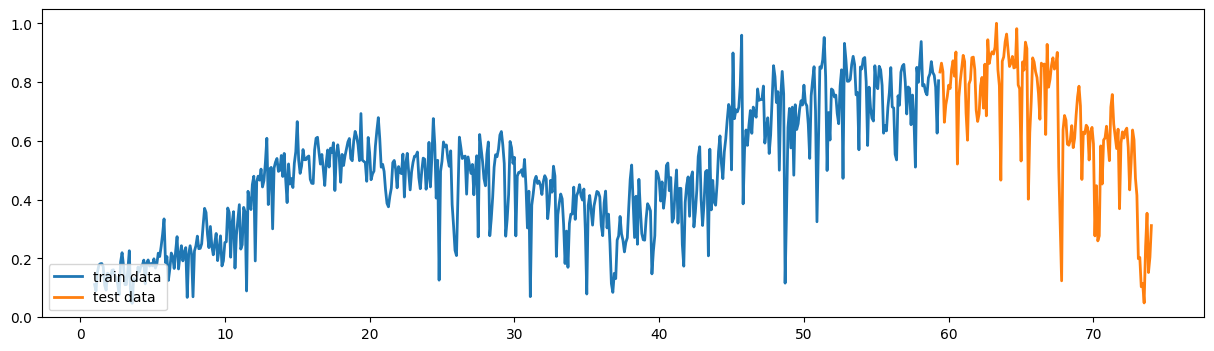

In [354]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

# Plot ONLY the cnt values
ax.plot(X_train, y_train[:, 0], lw=2, label='train data')
ax.plot(X_test,  y_test[:, 0],  lw=2, label='test data')

ax.legend(loc="lower left")
plt.show()


In the **second attempt** to improve the MAPE what i did is : 

- increase the look_back to 24

- increase the epochs to 100

Result : MAPE = 28.26 %

In the **third attempt** to improve the MAPE what i did is : 

- increase the look_back to 14

- epochs = 50

Result : MAPE = 26.78 % yet my prediction plot is weird : 

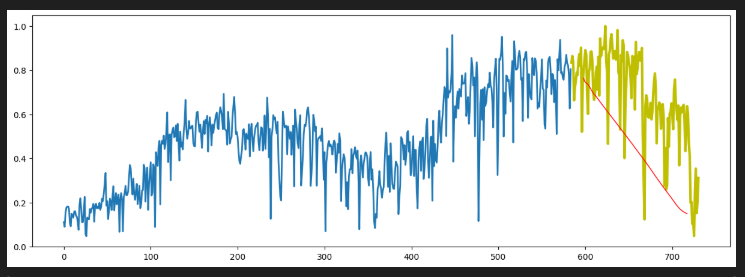 

In the **fourth attempt** to improve the MAPE what i did is : 

- increase the look_back to 18 

- epochs = 50
Result : MAPE = 27.84 % yet my prediction plot is weird : 

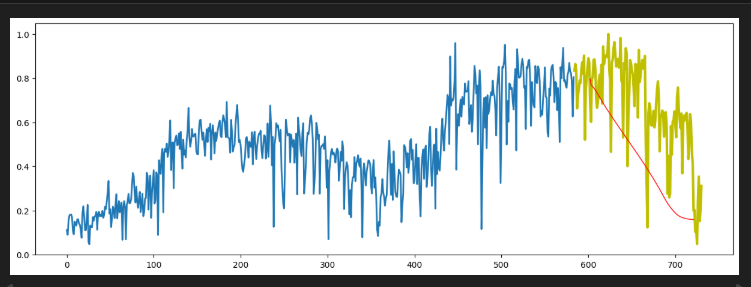

In the **fifth attempt** to improve the MAPE what i did is : 
I asked chatgpt how can i make MAPE improve and how can i fix my prediction plot and it advised me to : 

- keep the look_back at 14 
- epochs = 50
- add another feature : i used the heatmap to pick top three features to test 

**For feature one : registered**

Result : MAPE = 25.76 %, my predection plot is better :

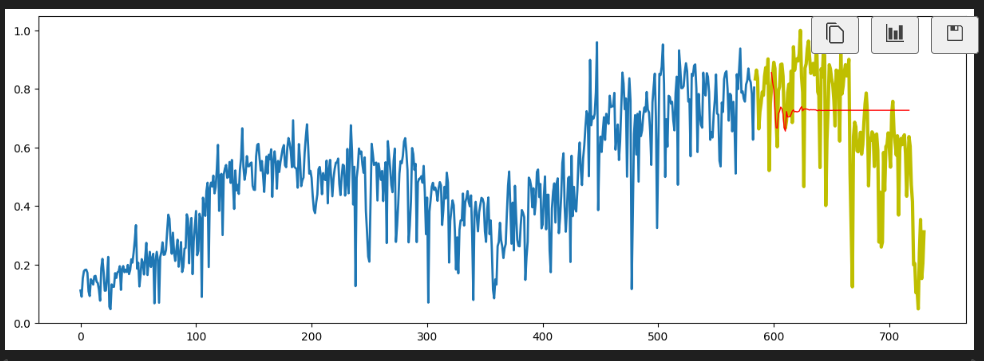 

**For feature two : casual**

Result : MAPE = 36.26 %, my predection plot is worse => Everything got worse : 

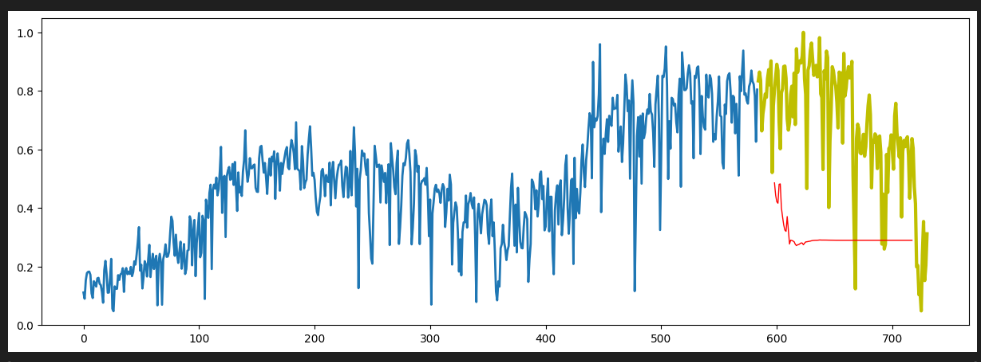

**For feature three : Temperature**

Result : MAPE = 30.38 %, my predection plot is a bit better => Everything got worse : 

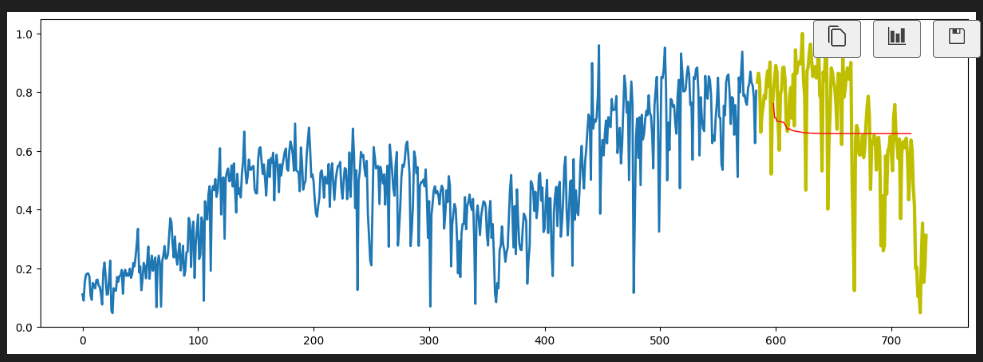


=> My conclusion for now, the best feature is registered i will try to improve the results 

In [355]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


look_back  = 4
batch_size = 1

train_generator = TimeseriesGenerator(train_series, train_series,
                                      length        = look_back, 
                                      sampling_rate = 1,
                                      stride        = 1,
                                      batch_size    = batch_size)

test_generator = TimeseriesGenerator(test_series, test_series,
                                      length        = look_back, 
                                      sampling_rate = 1,
                                      stride        = 1,
                                      batch_size    = batch_size)

In [356]:
from keras.models import Sequential
from keras import Input
from keras.layers import LSTM
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint

mc = ModelCheckpoint('best_model_count_forecasting.keras',
                     monitor='val_loss', 
                     mode='min', 
                     save_best_only=True)

callback_list = [mc]

n_neurons  = 32

model = Sequential()
model.add(Input(shape=(look_back, 
                       n_features)))

model.add(LSTM(n_neurons, 
               activation="relu"))

model.add(Dense(1))

model.compile(optimizer='adam', 
              loss='mse')


model.fit(train_generator, 
          epochs=100, 
          verbose=1, 
          validation_data=test_generator, 
          callbacks=callback_list)


Epoch 1/100


C:\Users\Chourouk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


580/580 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0343 - val_loss: 0.0267
Epoch 2/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0140 - val_loss: 0.0250
Epoch 3/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0131 - val_loss: 0.0231
Epoch 4/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0130 - val_loss: 0.0234
Epoch 5/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0121 - val_loss: 0.0219
Epoch 6/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0207
Epoch 7/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - val_loss: 0.0202
Epoch 8/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0117 - val_loss: 0.0207
Epoch 9/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0117 - val_loss: 0.0217
Epoch 10/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - val_loss: 0.0220
Epoch 11/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0119 - val_loss: 0.0203
Epoch 12/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

<Axes: >

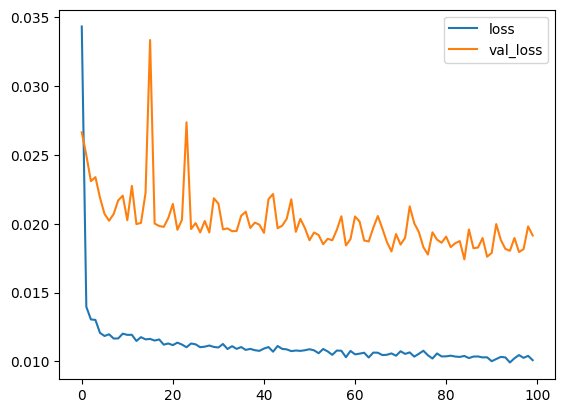

In [357]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [358]:
from keras.models import load_model
model = load_model("best_model_count_forecasting.keras")

In [359]:
# TensorFlow evaluation metrics
result = model.evaluate(train_generator)
print(f"Training loss: {result}")

# test loss
result = model.evaluate(test_generator)
print(f"Testing loss: {result}")

580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0099
Training loss: 0.009934509173035622
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0174
Testing loss: 0.017414359375834465


In [360]:
test_predictions  = model.predict(test_generator)

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Actually i tested this because when i first runned the code i got a very weird MAPE : 

MAPE (mean average precision error):
2153738591806982.0 %

and by trying to invistigate how it can explode i discovered that this happens when there's a 0 in my actual_y_test

As a second attempt by fixing the 0 value i managed to have a normal MAPE = 27% but this is still very big as a metrics and what i will try to do next is minimize it 

In [361]:
# (actual_y_test == 0).sum()
# it's 0 now after my fix it should be ok now but it should not be executed after the fix

In [362]:
actual_y_test = np.concatenate([y for x, y in test_generator])
mape = mean_absolute_percentage_error(actual_y_test[:, 0], test_predictions[:, 0]) * 100

# print out the MAPE-score
print("MAPE (mean average precision error):")
print(f"{round(mape, 2)} %")

# MAE - Mean average error
print("\nMAE")
print(round(metrics.mean_absolute_error(actual_y_test[:, 0], test_predictions[:, 0]), 2), "rentals")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(actual_y_test[:, 0], test_predictions[:, 0]), 2), "rentals^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(actual_y_test[:, 0], test_predictions[:, 0])), 2), "rentals")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(actual_y_test[:, 0], test_predictions[:, 0]), 2))

MAPE (mean average precision error):
22.52 %

MAE
0.09 rentals

MSE
0.02 rentals^2

RMSE:
0.12 rentals

R-squared:
0.66


This is the best R-squared i could've get, i tried a lot of combination i changed all the paramaters but i couldn't get better

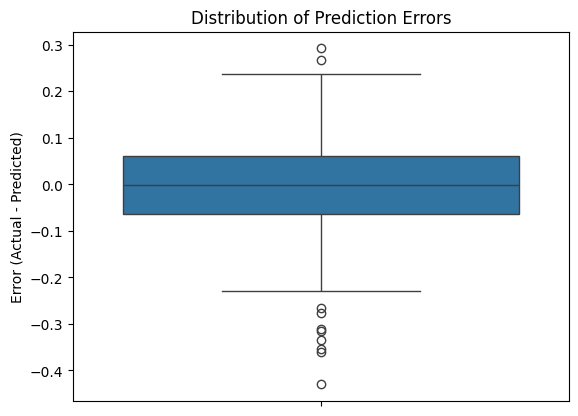

In [363]:
comparison = pd.DataFrame({
    "actual cnt": actual_y_test[:, 0].flatten(),
    "predicted cnt": test_predictions[:, 0].flatten(),
    "difference": actual_y_test[:, 0].flatten() - test_predictions[:, 0].flatten()
})
sns.boxplot(data=comparison, y='difference')
plt.title('Distribution of Prediction Errors')
plt.ylabel('Error (Actual - Predicted)')
plt.show()

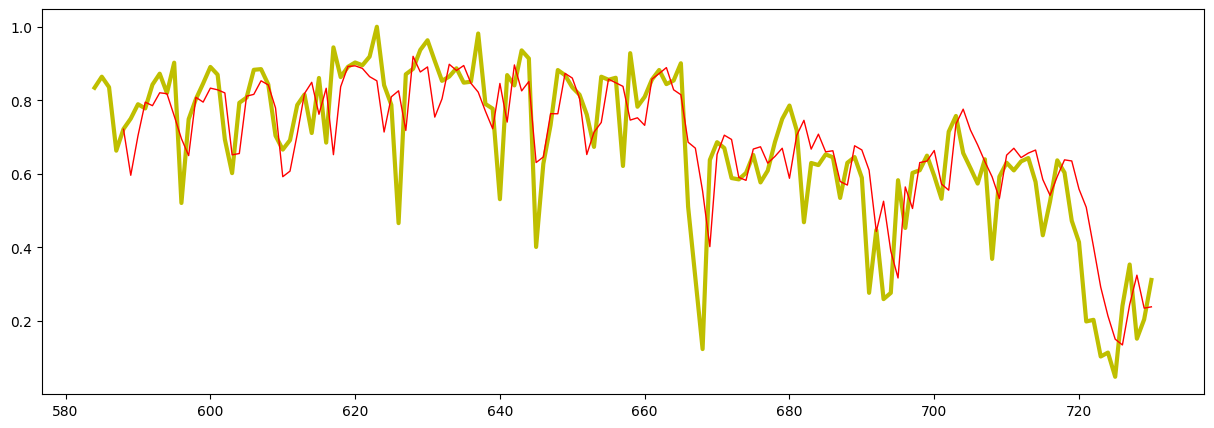

In [364]:
x1 = np.arange(0, len(y_train[:, 0]))
x2 = np.arange(len(y_train[:, 0]), len(y_train[:, 0]) + len(y_test[:, 0]))
x3 = np.arange(len(y_train[:, 0]) + look_back, len(y_train[:, 0]) + len(y_test[:, 0]))

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(x2, y_test[:, 0], lw=3, c='y', label='test data')
ax.plot(x3, test_predictions, lw=1, c='r', label='predictions')
plt.show()

In [365]:
# TensorFlow evaluation metrics
result = model.evaluate(train_generator)
print(f"Training loss: {result}")

# test loss
result = model.evaluate(test_generator)
print(f"Testing loss: {result}")

580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0099
Training loss: 0.009934509173035622
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0174
Testing loss: 0.017414359375834465


In [366]:
extrapolation = list()
seed_batch    = y_test[:look_back].reshape((1,look_back, n_features))
current_batch = seed_batch

# extrapolate the next 180 values
for i in range(120):
    predicted_cnt = model.predict(current_batch, verbose=None)[0][0]
    
    # get the last known value of feature 2 
    last_known_feature2 = current_batch[0, -1, 1]   
    
    # build a full 2-feature row for the next timestep
    next_step = np.array([predicted_cnt, last_known_feature2])
    
    # append prediction of cnt to the extrapolation list
    extrapolation.append(predicted_cnt)
    
    current_batch = np.append(
        current_batch[:, 1:, :],          
        next_step.reshape(1, 1, n_features),
        axis=1
    )

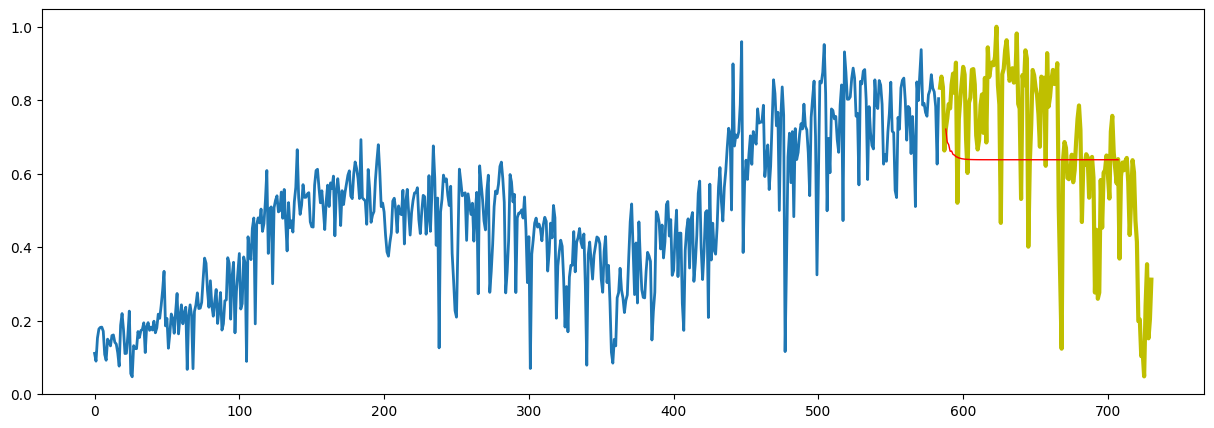

In [367]:
x1 = np.arange(0, len(y_train))
x2 = np.arange(len(y_train), len(y_train) + len(y_test))
x3 = np.arange(len(y_train) + look_back, len(y_train) + len(extrapolation) + look_back)

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(x1, y_train[:, 0], lw=2, label='train data')
ax.plot(x2, y_test[:, 0], lw=3, c='y', label='test data')
ax.plot(x3, extrapolation, lw=1, c='r', label='predictions')
plt.show()

In [368]:
df_extra = pd.DataFrame(data=extrapolation)

In [369]:
df_extra.describe()

,0
count,120.000000
mean,0.640338
std,0.010000
min,0.637991
25%,0.637991
50%,0.637991
75%,0.638005
max,0.721357


In [370]:
df_extra.var()

0    0.0001
dtype: float32

My Reflection on the whole exercise : 

This exercise was challenging as i had to spend hours trying to make my meterics look better and even though i managed to get a better meterics, because i started with R-squared around 0.4, the predections are not that good. It was a good practice because it pushed me beyond chatgpt's anwsers and any other AI's answers i had to read a bit what people are doing and what they're thinking about enhancing some meterics. I tried to work with the hours dataset but as it was a very messy data i couldn't really make it especially as it has a lot of 0 and MAPE is sensitive to this.